# ❤️ Heart Disease Prediction - End-to-End Machine Learning Project


In [21]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score,classification_report,
                             confusion_matrix,roc_auc_score,RocCurveDisplay)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import joblib


## 1. Load Dataset

In [22]:
df=pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [23]:
print(df.shape)
display(df.describe().T)
df.info()

(1025, 14)


,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


## 2. Data Quality

In [24]:
print(df.isnull().sum())
print("\nDuplicate rows:",df.duplicated().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate rows: 723


## 3. Exploratory Data Analysis

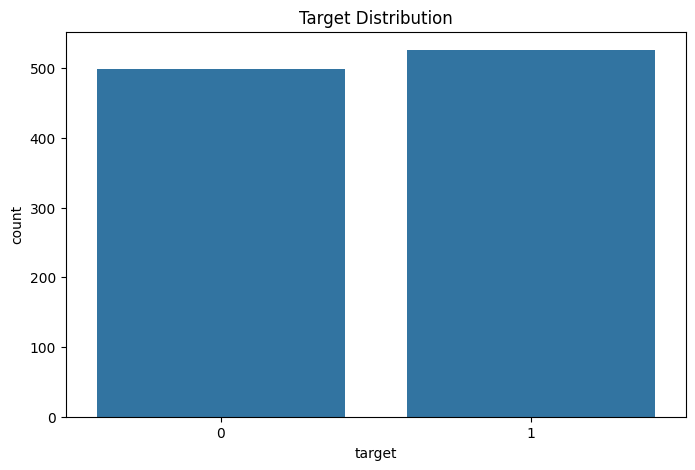

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(x='target',data=df)
plt.title('Target Distribution')
plt.show()

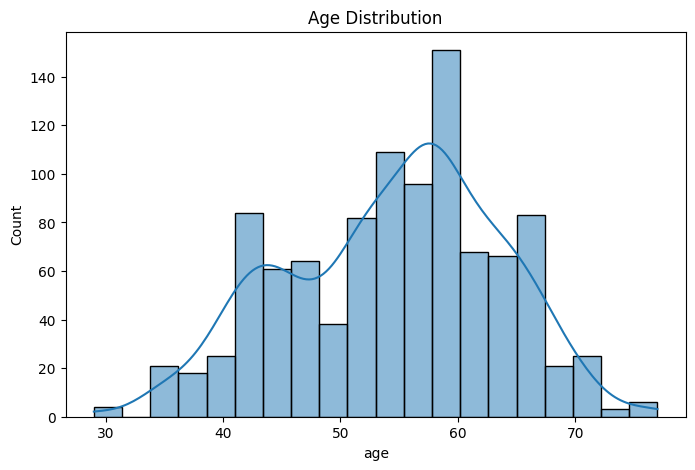

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'],bins=20,kde=True)
plt.title('Age Distribution')
plt.show()

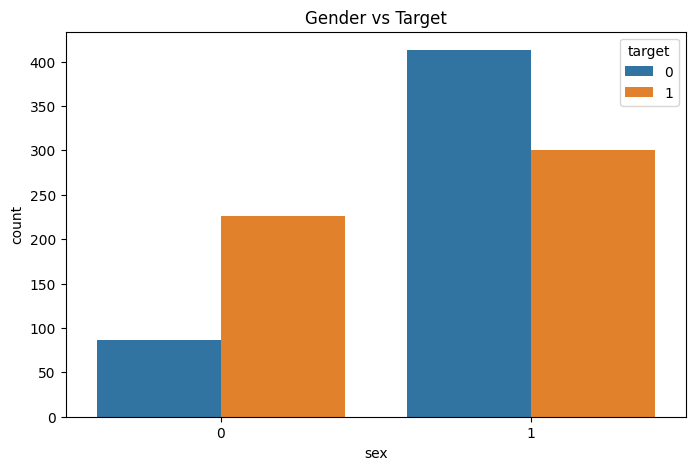

In [27]:
plt.figure(figsize=(8,5))
sns.countplot(x='sex',hue='target',data=df)
plt.title('Gender vs Target')
plt.show()

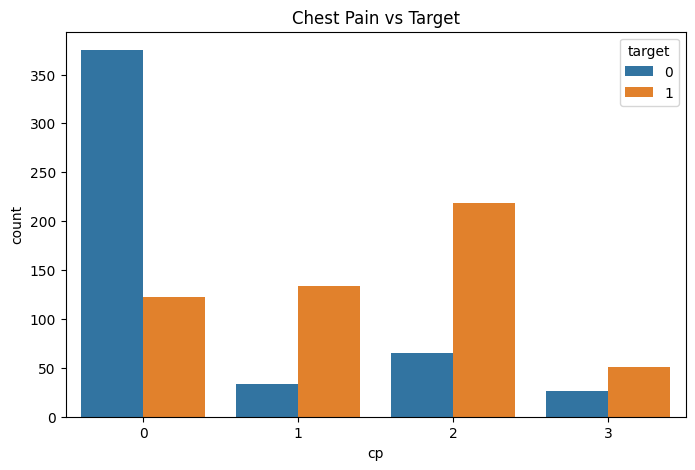

In [28]:
plt.figure(figsize=(8,5))
sns.countplot(x='cp',hue='target',data=df)
plt.title('Chest Pain vs Target')
plt.show()

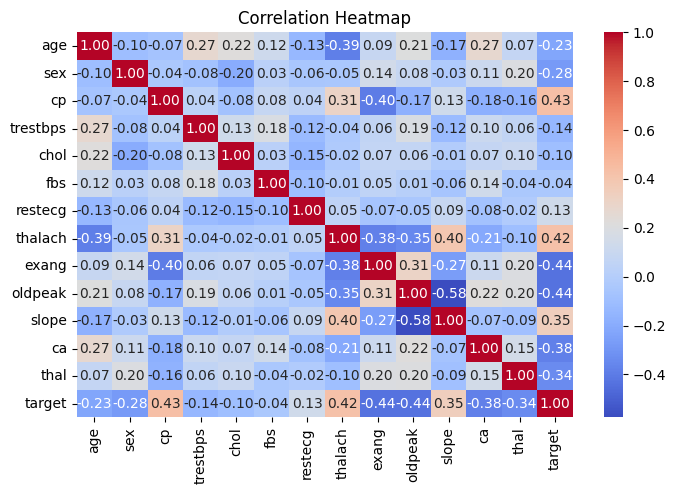

In [29]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## 4. Prepare Data

In [30]:
X=df.drop('target',axis=1)
y=df['target']

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)

print(X_train.shape,X_test.shape)


(820, 13) (205, 13)


## 5. Train Multiple Models

In [31]:
models={
'Logistic Regression':Pipeline([('scaler',StandardScaler()),
('model',LogisticRegression(max_iter=1000))]),
'Decision Tree':DecisionTreeClassifier(random_state=42),
'Random Forest':RandomForestClassifier(random_state=42),
'Gradient Boosting':GradientBoostingClassifier(random_state=42),
'KNN':Pipeline([('scaler',StandardScaler()),
('model',KNeighborsClassifier())]),
'SVM':Pipeline([('scaler',StandardScaler()),
('model',SVC(probability=True))])
}

results=[]

for name,model in models.items():
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    acc=accuracy_score(y_test,pred)
    results.append([name,acc])

results_df=pd.DataFrame(results,columns=['Model','Accuracy']).sort_values('Accuracy',ascending=False)
results_df

,Model,Accuracy
2,Random Forest,1.000000
1,Decision Tree,0.985366
3,Gradient Boosting,0.975610
5,SVM,0.926829
4,KNN,0.863415
0,Logistic Regression,0.809756


## 6. Hyperparameter Tuning (Random Forest)

In [32]:
params={
'n_estimators':[100,200,300],
'max_depth':[None,5,10],
'min_samples_split':[2,5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=5,
    scoring='accuracy',
    n_jobs=1
)

grid.fit(X_train,y_train)

best_model=grid.best_estimator_

print(grid.best_params_)


{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}


## 7. Final Evaluation

In [33]:
pred=best_model.predict(X_test)
proba=best_model.predict_proba(X_test)[:,1]

print("Accuracy:",accuracy_score(y_test,pred))
print("ROC-AUC:",roc_auc_score(y_test,proba))
print(classification_report(y_test,pred))


Accuracy: 1.0
ROC-AUC: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



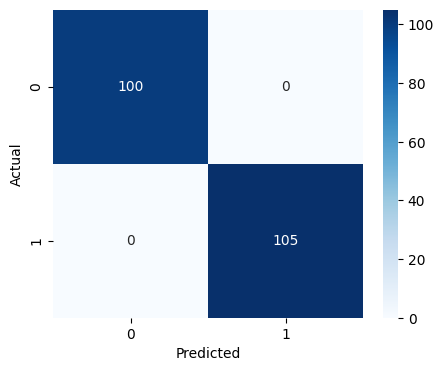

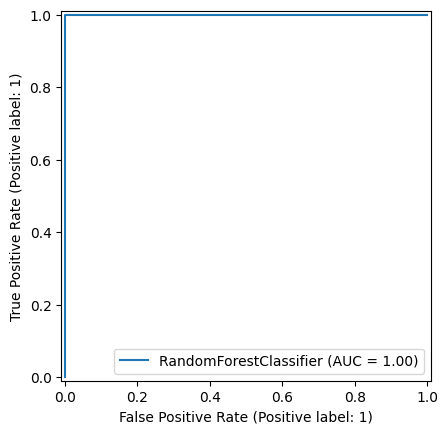

In [34]:
cm=confusion_matrix(y_test,pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

RocCurveDisplay.from_estimator(best_model,X_test,y_test)
plt.show()


## 8. Feature Importance

In [35]:
importance=pd.DataFrame({
'Feature':X.columns,
'Importance':best_model.feature_importances_
}).sort_values('Importance',ascending=False)

importance

,Feature,Importance
2,cp,0.148501
11,ca,0.112857
7,thalach,0.111074
12,thal,0.104263
9,oldpeak,0.104091
0,age,0.091209
4,chol,0.075798
8,exang,0.075113
3,trestbps,0.071524
10,slope,0.045114


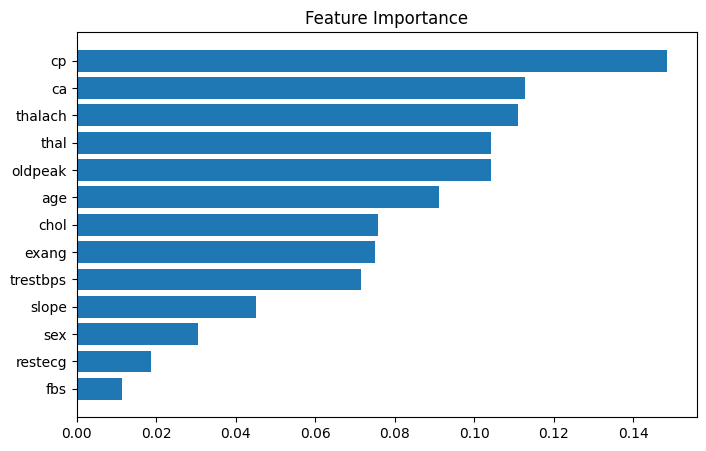

In [36]:
plt.figure(figsize=(8,5))
plt.barh(importance['Feature'],importance['Importance'])
plt.gca().invert_yaxis()
plt.title('Feature Importance')
plt.show()

## 9. Save Model

In [37]:
joblib.dump(best_model,'heart_disease_model.pkl')
print('Model saved.')

Model saved.


## 10. Predict New Patient

In [38]:
# User Input

age = int(input("Enter Age: "))
sex = int(input("Enter Gender (1=Male, 0=Female): "))
cp = int(input("Enter Chest Pain Type (0-3): "))
trestbps = int(input("Enter Resting Blood Pressure: "))
chol = int(input("Enter Cholesterol: "))
fbs = int(input("Enter Fasting Blood Sugar (1=True, 0=False): "))
restecg = int(input("Enter Resting ECG (0-2): "))
thalach = int(input("Enter Maximum Heart Rate: "))
exang = int(input("Exercise Induced Angina (1=Yes, 0=No): "))
oldpeak = float(input("Enter Old Peak: "))
slope = int(input("Enter Slope (0-2): "))
ca = int(input("Enter Number of Major Vessels (0-3): "))
thal = int(input("Enter Thal (0=Normal, 1=Fixed Defect, 2=Reversible Defect): "))

new_data = pd.DataFrame({
    "age": [age],
    "sex": [sex],
    "cp": [cp],
    "trestbps": [trestbps],
    "chol": [chol],
    "fbs": [fbs],
    "restecg": [restecg],
    "thalach": [thalach],
    "exang": [exang],
    "oldpeak": [oldpeak],
    "slope": [slope],
    "ca": [ca],
    "thal": [thal]
})

prediction = best_model.predict(new_data)
probability = best_model.predict_proba(new_data)[0][1]

print("\nPrediction Result")
print("-" * 30)

if prediction[0] == 1:
    print("❤️ High Risk of Heart Disease")
else:
    print("💚 Low Risk of Heart Disease")

print(f"Probability: {probability:.2%}")



Prediction Result
------------------------------
❤️ High Risk of Heart Disease
Probability: 62.00%


## 11. Conclusions
- Compared multiple models.
- Tuned Random Forest.
- Evaluated with accuracy and ROC-AUC.
- Saved the best model for deployment.